# Seismic Modeling

In [1]:
from geod67lib.wavefield import *
from geod67lib.wavefield.damp import generate_damp_mask
from geod67lib.plotting import plot_image, plot_seismogram

from geod67lib import fd

import numpy as np
from scipy.ndimage import gaussian_filter

import matplotlib.pyplot as plt

import tensorflow as tf

2026-06-30 23:04:43.177917: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# shape = (301, 301)
# shape = (170, 80)
# shape = (1, 256, 256, 1)
shape = (1, 128, 128, 1)
# h = (10, 10)
h = (20, 20)
# h = (5, 5)

nbl = 20

fd_order = 4

# vp_data = 1.5 * np.ones(shape, dtype=np.float32)
# vp_data[:,shape[1]//2:] = 3

# vp_data = np.fromfile('./data/marmo_vp_nx256nz256dx10dz10.bin', dtype=np.float32).reshape(shape)
vp_data = np.fromfile(f'./data/marmo_vp_nx{shape[1]}nz{shape[2]}dx{h[0]}dz{h[0]}.bin', dtype=np.float32).reshape(shape)

vp_data = np.pad(vp_data[0,:,:,0], nbl, mode='edge')
vp_data = vp_data.reshape((1, *vp_data.shape, 1))
# damp_mask = np.zeros_like(vp_data)
damp_mask = generate_damp_mask(vp_data, nbl)

vp = VelocityModel(vp_data, h[0], h[1], nbl)

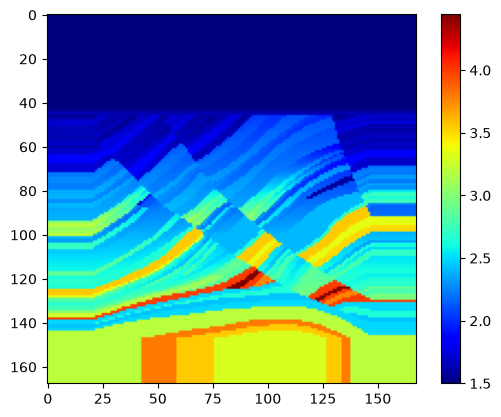

In [3]:
plot_image(vp_data, cmap='jet')

In [4]:
src_positions = np.array([[vp.shape[1]//2, nbl]], dtype=np.int32)

# nrec = (shape[0] - 2*nbl)//2
nrec = (vp.shape[1] - 2*nbl)

rec_positions = np.array([
    [xr, nbl] for xr in np.linspace(nbl, vp.shape[1] - nbl, dtype=np.int32, num=nrec)
], dtype=np.int32)

In [5]:
rec_positions

array([[ 20,  20],
       [ 21,  20],
       [ 22,  20],
       [ 23,  20],
       [ 24,  20],
       [ 25,  20],
       [ 26,  20],
       [ 27,  20],
       [ 28,  20],
       [ 29,  20],
       [ 30,  20],
       [ 31,  20],
       [ 32,  20],
       [ 33,  20],
       [ 34,  20],
       [ 35,  20],
       [ 36,  20],
       [ 37,  20],
       [ 38,  20],
       [ 39,  20],
       [ 40,  20],
       [ 41,  20],
       [ 42,  20],
       [ 43,  20],
       [ 44,  20],
       [ 45,  20],
       [ 46,  20],
       [ 47,  20],
       [ 48,  20],
       [ 49,  20],
       [ 50,  20],
       [ 51,  20],
       [ 52,  20],
       [ 53,  20],
       [ 54,  20],
       [ 55,  20],
       [ 56,  20],
       [ 57,  20],
       [ 58,  20],
       [ 59,  20],
       [ 60,  20],
       [ 61,  20],
       [ 62,  20],
       [ 63,  20],
       [ 64,  20],
       [ 65,  20],
       [ 66,  20],
       [ 67,  20],
       [ 68,  20],
       [ 69,  20],
       [ 70,  20],
       [ 71,  20],
       [ 72,

In [6]:
vp_data.max()

np.float32(4.45)

In [7]:
# dt = 1  # ms
dt = 2  # ms
tn = 3000 # ms
# fpeak = 10 * 1e-3
# fpeak = 5 * 1e-3
fpeak = 8 * 1e-3

src_wavelet = np.array([ricker(fpeak, dt, int(tn//dt))])

In [8]:
ap = AquisitionParameters(src_positions, rec_positions, dt, tn, src_wavelet)

In [9]:
op = WaveSolverOperator(ap)

In [10]:
u_history = op.forward(vp, damp_mask, True, fd_order=fd_order)

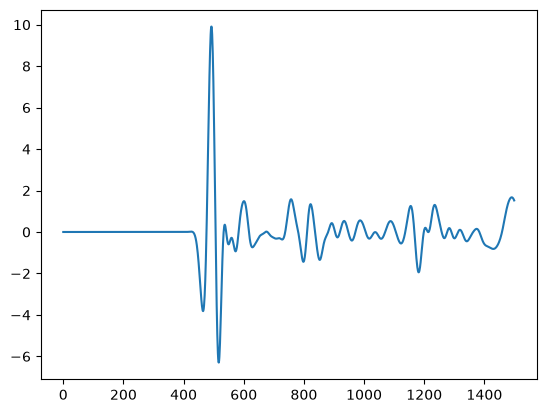

In [11]:
plt.plot(ap.rec_data[0])

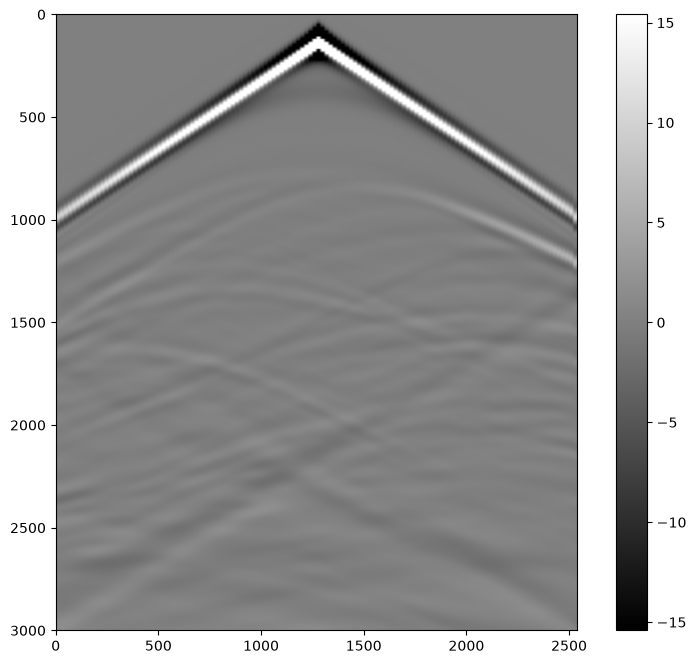

In [12]:
plot_seismogram(ap.rec_data, vp.inner_width, tn)

In [13]:
len(u_history)

1500

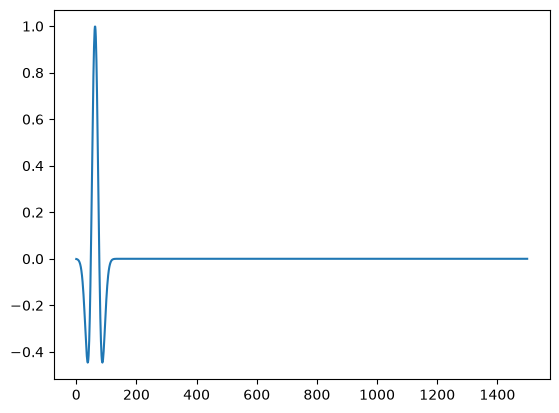

In [14]:
plt.plot(ricker(fpeak, dt, tn//dt))

In [15]:
ap.nt

1500

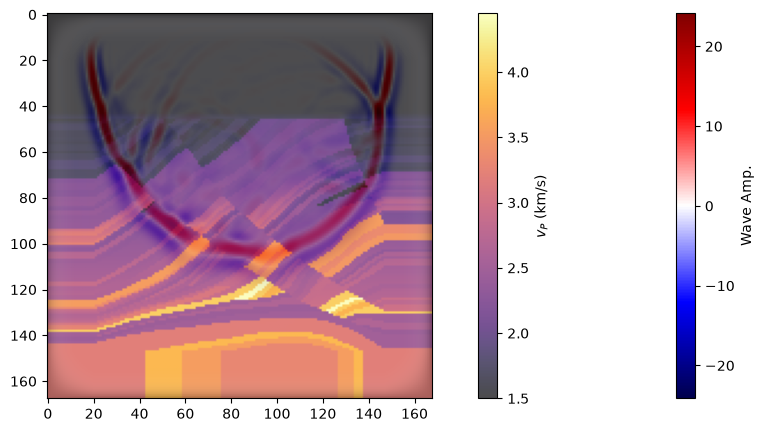

In [16]:
idx = 500
vmax = np.abs(u_history[idx]).max()
plt.figure(figsize=(15,5))
plt.imshow(tf.transpose(u_history[idx][0, :, :, 0]) - np.median(u_history[idx][0, :, :, 0]), cmap='seismic', vmax=vmax , vmin=-vmax)
# plt.imshow(u_history[idx].T - u_history[idx-1].T, cmap='seismic', vmax=vmax , vmin=-vmax)
plt.colorbar(label='Wave Amp.')
plt.imshow(tf.transpose(vp.data[0, :, :, 0]), cmap='inferno', alpha=0.7, vmin = vp.data.min(), vmax=vp.data.max())
plt.colorbar(label='$v_P$ (km/s)')
plt.imshow(tf.transpose(1-damp_mask)[0,:,:,0], cmap='grey', alpha=tf.transpose(damp_mask)[0,:,:,0]/4)

# plt.scatter
# plt.colorbar(label='$v_P$ (km/s)')

## Migration (1 Src)

In [17]:
apT = ap.adjoint_parameters()

In [18]:
opT = WaveSolverOperator(apT)

In [19]:
v_history = opT.forward(vp, damp_mask, True, fd_order=fd_order)

In [20]:
len(v_history)

1500

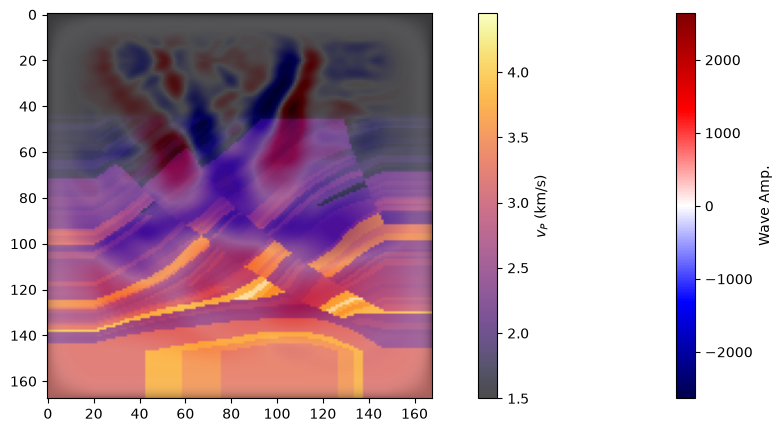

In [21]:
idx = 600
vmax = np.abs(v_history[idx][0, :, :, 0]).max()
plt.figure(figsize=(15,5))
plt.imshow(tf.transpose(v_history[idx][0, :, :, 0]) - np.median(v_history[idx][0, :, :, 0]), cmap='seismic', vmax=vmax , vmin=-vmax)
# plt.imshow(u_history[idx].T - u_history[idx-1].T, cmap='seismic', vmax=vmax , vmin=-vmax)
plt.colorbar(label='Wave Amp.')
plt.imshow(tf.transpose(vp.data[0, :, :, 0]), cmap='inferno', alpha=0.7, vmin = vp.data.min(), vmax=vp.data.max())
plt.colorbar(label='$v_P$ (km/s)')
plt.imshow(tf.transpose(1-damp_mask)[0,:,:,0], cmap='grey', alpha=tf.transpose(damp_mask)[0,:,:,0]/4)

# plt.scatter
# plt.colorbar(label='$v_P$ (km/s)')

In [22]:
zeta = tf.zeros_like(u_history[0])
illum = tf.zeros_like(u_history[0])

for ti in range(ap.nt):
    ui = u_history[ti]
    vi = v_history[-(ti+1)]

    illum = tf.add(illum, ui*ui)
    # illum += ui**2
    zeta = tf.add(zeta, ui * vi)
    # zeta += ui * vi

## Migration

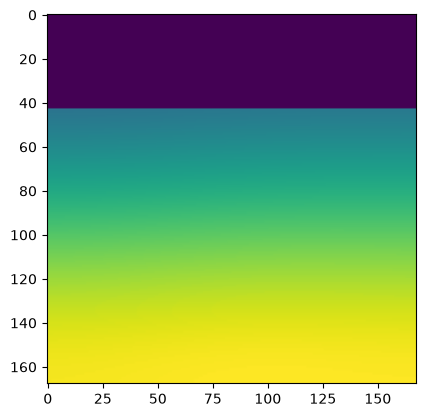

In [23]:
sigma = 64
vp0_data = gaussian_filter(vp.data, sigma)
vp0_data[vp_data <= 1.51] = vp_data[vp_data <= 1.51]
vp0 = VelocityModel(vp0_data, vp.hx, vp.hz)
plt.imshow(tf.transpose(vp0_data[0,:,:,0]))

In [24]:
nsrc=5

In [25]:
sx = np.linspace(nbl, vp.shape[1] - nbl-1, num=nsrc, dtype=np.int32)
sx

array([ 20,  51,  83, 115, 147], dtype=int32)

In [26]:
ap2 = ap.copy()
ap2.src_positions = np.zeros((nsrc, 2), dtype=np.int32)
ap2.src_positions[:, 0] = sx
ap2.save('./data/aquisition-params.json')

In [27]:
dobs = []
for sxi in sx:
    print(f'Modeling shot for source at ({sxi},0).')
    ap.reset()
    ap.src_positions[0][0] = sxi

    op.forward(vp, damp_mask, fd_order=fd_order)
    dobs.append(ap.rec_data)

dobs = tf.stack(dobs)

Modeling shot for source at (20,0).


Modeling shot for source at (51,0).
Modeling shot for source at (83,0).
Modeling shot for source at (115,0).
Modeling shot for source at (147,0).


In [28]:
dobs.shape

TensorShape([5, 128, 1500])

In [40]:
def compute_image(i):
    ap.reset()
    ap.src_positions[0][0] = sx[i]

    u_history = op.forward(vp0, damp_mask, True, fd_order=fd_order)

    res = (ap.rec_data - dobs[i]).numpy()
    res = np.flip(res, axis=1)
    apT.reset()
    apT.src_wavelet = res

    v_history = opT.forward(vp0, damp_mask, True, fd_order=fd_order)
    v_history = list(reversed(v_history))
    
    zeta = tf.zeros_like(u_history[0])
    illum = tf.zeros_like(u_history[0])

    
    # for ti in range(ap.nt):
    #     ui = u_history[ti]
    #     ui_1 = u_history[ti-1] if ti > 0 else u_history[ti]
    #     # vi = v_history[-(ti+1)]
    #     vi = v_history[ti]
    #     vi_1 = v_history[ti-1] if ti > 0 else v_history[ti]
    
    #     illum += ui*ui
    #     # zeta += fd.lap(ui, vp.hx, vp.hz) * vi
    #     # zeta += (ui - ui_1)/ap.dt * (vi - vi_1)/ap.dt * 1/vp0.data**2 - (fd.lap(ui, vp.hx, vp.hz, fd_order=fd_order)) * vi
    #     zeta += (ui - ui_1)/ap.dt * (vi - vi_1)/ap.dt

    zeta = imaging_condition(zeta, illum, u_history, v_history, ap.nt, ap.dt)

    zeta = 2/(vp0.data*vp0.data*vp0.data) * zeta.numpy()
    zeta[vp.data <=1.51] = 0

    return zeta, illum


@tf.function
def imaging_condition(zeta, illum, u_history, v_history, nt, dt):
    for ti in range(nt):
        ui = u_history[ti]
        ui_1 = u_history[ti-1] if ti > 0 else u_history[ti]
        # vi = v_history[-(ti+1)]
        vi = v_history[ti]
        vi_1 = v_history[ti-1] if ti > 0 else v_history[ti]
    
        illum += ui*ui
        # zeta += fd.lap(ui, vp.hx, vp.hz) * vi
        # zeta += (ui - ui_1)/ap.dt * (vi - vi_1)/ap.dt * 1/vp0.data**2 - (fd.lap(ui, vp.hx, vp.hz, fd_order=fd_order)) * vi
        zeta += (ui - ui_1)/dt * (vi - vi_1)/dt
    return zeta

    

In [41]:
zeta_full = np.zeros_like(vp0.data)
illum_full = np.zeros_like(vp0.data)
for i in range(len(sx)):
    print(i+1, '/', len(sx))
    zi, ii = compute_image(i)
    zeta_full += zi
    illum_full += ii

zeta_full /= (illum + 1e-9)

1 / 5
2 / 5
3 / 5
4 / 5
5 / 5


<Figure size 640x480 with 0 Axes>

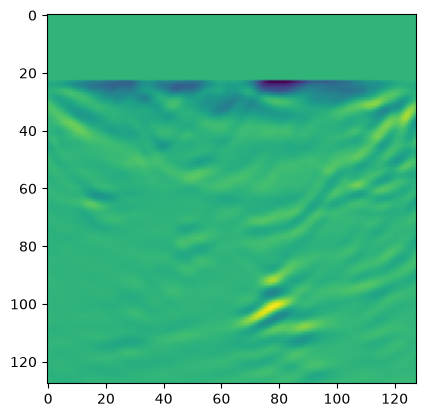

<Figure size 640x480 with 0 Axes>

In [31]:
plt.imshow(zeta_full.numpy().T[0, nbl:-nbl, nbl:-nbl, 0])
# plt.imshow(zeta_full.T[0, nbl:-nbl, nbl:-nbl, 0])
plt.figure()

In [32]:
dobs.numpy().tofile(f'./data/dobs_nx{shape[1]}nz{shape[2]}dx{h[0]}dz{h[1]}.bin')

In [33]:
zeta_full[0, nbl:-nbl, nbl:-nbl, 0].numpy().tofile(f'./data/mig_nx{shape[1]}nz{shape[2]}dx{h[0]}dz{h[1]}.bin')

In [34]:
vp0_data[0, nbl:-nbl, nbl:-nbl, 0].tofile(f'./data/vp0_nx{shape[1]}nz{shape[2]}dx{h[0]}dz{h[1]}.bin')

In [35]:
(vp_data > 1.51)[0, nbl:-nbl, nbl:-nbl, 0].tofile(f'./data/watermask_nx{shape[1]}nz{shape[2]}dx{h[0]}dz{h[1]}.bin')